In [1]:
# coding: utf-8

'''Script to invert Tongariro SP data using streaming current density

Soegi Kang, Stanford
Dominique Fournier, Mira Geoscience,
Craig Miller, GNS

https://github.com/simpeg

12 July 2024
Updated to run on SimPEG version 0.22  32Gb ram are recommended to run the model.

'''

from simpeg import utils, maps, directives, data_misfit, regularization, optimization, inversion, inverse_problem, data
from simpeg.electromagnetics.static import self_potential as sp
import simpeg.electromagnetics.static as em_static
import simpeg.electromagnetics.static.utils as staticutils
from simpeg.utils import download
#import simpeg.dask
from pymatsolver import PardisoSolver
import discretize as Mesh
from discretize.utils import refine_tree_xyz, active_from_xyz
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma

import os
from sklearn.metrics import mean_squared_error as mse
from matplotlib.ticker import AutoMinorLocator
#import colorcet as cc

import tarfile

tar_folder = download( "https://storage.googleapis.com/simpeg/miller_et_al_2018.tar.gz")  
tar = tarfile.open(tar_folder, "r:*")
tar.extractall()
tar.close()

datadir ="./miller_et_al_2018/"

plt.close('all')

file already exists, new file is called /Users/sgkang09/Project/miller2018_Tongariro_SP_inversion/notebooks/miller_et_al_2018.tar.gz
   saved to: /Users/sgkang09/Project/miller2018_Tongariro_SP_inversion/notebooks/miller_et_al_2018.tar.gz
Download completed!


In [2]:
#Load data, conductivity and topo files

topo = np.loadtxt(datadir + 'topoxyz.dat', skiprows=1)
dataInv = np.loadtxt(datadir + 'Tongariro_SP_data.dat')

cond_model_file = datadir + 'MT_model_for_SP_inv.con'
mesh_file = datadir + 'Tongariro_SP.msh'


In [3]:
dataInv.shape

(679, 3)

In [4]:
#read in and set up mesh

topo = topo[(topo[:,0] < 1833000) & (topo[:,0] > 1824000)]
topo = topo[(topo[:,1] > 5662000) & (topo[:,1] < 5670000)]

topoInv = topo

#set reference electrode location
xref, yref = 1830000, 5666000

#Read in the mesh
mesh = Mesh.TensorMesh.read_UBC(mesh_file)

print( mesh)
print( 'width in X direction', mesh.h[0].sum(), 'm')
print( 'width in Y direction', mesh.h[1].sum(), 'm')
print( 'width in Z direction', mesh.h[2].sum(), 'm')
print( 'number of cells', mesh.nC)



  TensorMesh: 450,296 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     77  1,824,200.00  1,832,281.00    100.00    207.00    1.20
   y     68  5,662,200.00  5,669,498.00    100.00    207.00    1.30
   z     86       -850.13      2,355.00     20.00    344.65    1.30


width in X direction 8081.0 m
width in Y direction 7298.0 m
width in Z direction 3205.133662 m
number of cells 450296


In [24]:
#sigma is background conductivity (S/m)

#read in conducitivity model file
resistivity = mesh.read_model_UBC(cond_model_file) #read background conductivity model from file
sigma = 1/resistivity #change to S/m from ohmm
active_cells = ~(sigma == 1e-8)
# active_cells = active_from_xyz(mesh, topoInv)
n_active = np.sum(active_cells) #number of active cells

# sets uniform conductivity background
#sigma = np.ones(mesh.nC)*1e-3
# sigma[~actind] = 1e-8 #sigma of cells above topo = 1e-8
air_conductivity = np.log(1e-8)


In [25]:
#set active cell maps for various usages
active_map = maps.InjectActiveCells(mesh, active_cells, np.exp(air_conductivity)) #makes cell below topo active and sets cells above topo to air conductivity
active_map_amp = maps.InjectActiveCells(mesh, active_cells, -100.) #makes cell below topo active and sets cells above topo to -100.
active_map_plot = maps.InjectActiveCells(mesh, active_cells, np.nan)


In [26]:
#drape points onto topo
xyzlocInv = staticutils.drapeTopotoLoc(mesh, dataInv[:,:2], actind=active_cells)
#xyzlocInv = np.c_[xyzlocInv[:,:2], xyzlocInv[:,2]]

In [27]:
# Depth weighting    # weight=0. to remove depth weighting.
mesh2D, topoCC = staticutils.gettopoCC(mesh, active_cells) 
weight = 2.
zlocCC = utils.mkvc(topoCC.reshape([-1,1]).repeat(mesh.shape_cells[2], axis=1))
depthweight = 1./ ((abs(mesh.gridCC[:,2] - zlocCC)+50.)**weight)
depthweight /= depthweight.max()
depthweight[~active_cells] = np.nan
zlocCC[~active_cells] = np.nan

In [28]:
#setup the survey
ind = np.argmin(abs(xyzlocInv[:, 0]-xref)+abs(xyzlocInv[:, 1]-yref))
inds = np.ones(xyzlocInv.shape[0], dtype='bool')
inds[ind] = False
xyzM = xyzlocInv[inds, :]
xyzN = np.atleast_2d(xyzlocInv[ind]).repeat(xyzM.shape[0], axis=0) #N is the reference location

rx = em_static.resistivity.receivers.Dipole(xyzM, xyzN, data_type='volt')
src = sp.sources.StreamingCurrents([rx], mesh=mesh, modelType="CurrentDensity", indActive=active_cells)
sp_survey = sp.Survey([src])
sp_survey.dobs = (dataInv[1:,2] - dataInv[0,2])

q_map = sp.CurrentDensityMap(mesh, active_cells)
simulation = sp.Simulation3DCellCentered(mesh, sigma=sigma, survey=sp_survey, qMap=q_map)
simulation.solver = PardisoSolver

In [44]:
#for cartesian 
dobs = (dataInv[1:,2] - dataInv[0,2])
sp_data = data.Data(survey=sp_survey, dobs=dobs)
#set noise floor
sp_data.standard_deviation = 30 #survey std dev in  mV
#survey.eps = abs(survey.dobs).max() * 0.05
sp_data.noise_floor = 60 # survey noise floor in mV

dmisfit = data_misfit.L2DataMisfit(simulation=simulation, data=sp_data)
regmap = maps.IdentityMap(nP = active_map.nP*3)

wires = maps.Wires(('jsx', active_map.nP), ('jsy', active_map.nP), ('jsz', active_map.nP))
reg_jsx = regularization.Sparse(mesh, mapping=wires.jsx, active_cells=active_cells)
reg_jsy = regularization.Sparse(mesh, mapping=wires.jsy, active_cells=active_cells)
reg_jsz = regularization.Sparse(mesh, mapping=wires.jsz, active_cells=active_cells)

reg = reg_jsx + reg_jsy + reg_jsz
opt = optimization.ProjectedGNCG(maxIter=100, maxIterCG=10, maxIterLS=20, tolX=1e-20, tolF=1e-20)
# opt = optimization.InexactGaussNewton(maxIter=40, maxIterLS=30, maxIterCG=30, tolCG=1e-3, tolX=1e-20, tolF=1e-20, tolG=1e-20, eps=1e-20)

sp_inverse_problem = inverse_problem.BaseInvProblem(dmisfit, reg, opt)
target_misfit = directives.TargetMisfit(chifact=1)


In [56]:
print (reg_jsx.alpha_s, reg_jsx.alpha_x, reg_jsx.alpha_y, reg_jsx.alpha_z)

1.0 400.0 400.0 400.0


In [45]:
# Create an inversion object
# run the cartesian L2 inversion.
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
update_sensitivity_weighting = directives.UpdateSensitivityWeights(every_iteration=True, threshold_value=1e-2)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=1)
beta_schedule = directives.BetaSchedule(coolingFactor=8, coolingRate=3)

#L2 only
sp_inversion = inversion.BaseInversion(sp_inverse_problem, directiveList=[update_sensitivity_weighting, starting_beta, beta_schedule, target_misfit, update_jacobi])

simulation.counter = opt.counter = utils.Counter()
#opt.LSshorten = 0.5

m0 = np.ones(active_map.nP*3)*0.001 #creates an initial starting model m0
reg.mref = m0


In [46]:
pred = simulation.dpred(m0)

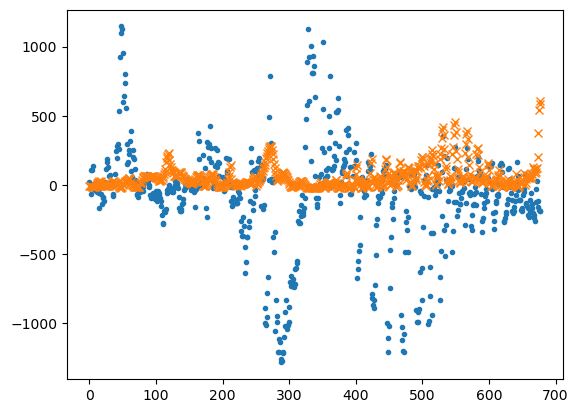

In [47]:
plt.plot(dobs, '.', color='C0')
plt.plot(pred, 'x', color='C1')

In [48]:
cartesian_L2_model = sp_inversion.run(m0) #mopt is the L2 output model


Running inversion with SimPEG v0.22.0
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.

                        simpeg.InvProblem is setting bfgsH0 to the inverse of the eval2Deriv.
                        ***Done using same Solver, and solver_opts as the Simulation3DCellCentered problem***
                        
model has any nan: 0
=============================== Projected GNCG ===============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
x0 has any nan: 0
   0  1.24e+00  3.37e+04  0.00e+00  3.37e+04    1.21e+05      0              
   1  1.24e+00  6.12e+03  3.81e+03  1.08e+04    5.25e+01      0              
   2  1.24e+00  6.12e+03  3.81e+03  1.08e+04    4.61e-02      0              
   3  1.55e-01  6.12e+03  3.

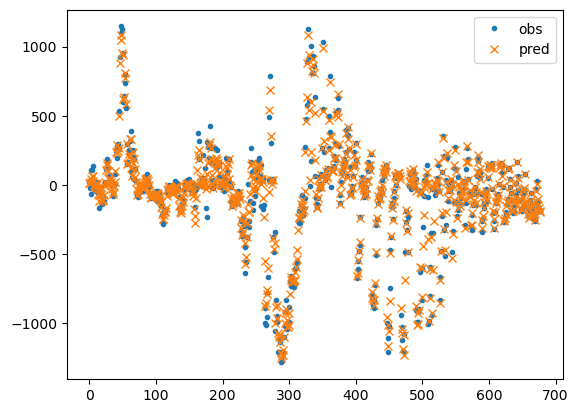

In [58]:
plt.plot(dobs, '.', color='C0', label='obs')
plt.plot(sp_inverse_problem.dpred, 'x', color='C1', label='pred')
plt.legend()

In [50]:
#############################################
# LAST STEP: Finish inversion with spherical formulation for sparsity
# Lp inversion starts here
# It uses the cartesian L2 model from above as a starting model
############################################

beta = 1.

mstart = utils.cartesian2spherical(cartesian_L2_model)
mref = np.zeros_like(mstart)

simulation.coordinate_system = 'spherical'
simulation.model = mstart

# Create a block diagonal regularization
wires = Maps.Wires(('amp', active_map.nP), ('theta', active_map.nP), ('phi', active_map.nP))

# Create a regularization
reg_a = regularization.Sparse(mesh, indActive=actind, mapping=wires.amp)
reg_a.norms = [0, 2, 2, 2]
#reg_a.eps_p = np.percentile(np.abs(mstart[:actMap.nP]), 95)
reg_a.mref = mref

reg_t = regularization.Sparse(mesh, indActive=actind, mapping=wires.theta)
reg_t.alpha_s = 0.  # No reference angle
reg_t.coordinate_system = 'spherical'
reg_t.norms = [2, 2, 2, 2] #0,1,1,1
#reg_t.eps_q = 1e-2 # in radians
reg_t.mref = mref
# reg_t.alpha_x, reg_t.alpha_y, reg_t.alpha_z = 0.25, 0.25, 0.25

reg_p = regularization.Sparse(mesh, indActive=actind, mapping=wires.phi)
reg_p.alpha_s = 0.  # No reference angle
reg_p.coordinate_system = 'spherical'
reg_p.norms = [2, 2, 2, 2] #0,1,1,1
#reg_p.eps_q = 1e-2 # in radians
reg_p.mref = mref

reg = reg_a + reg_t + reg_p
reg.mref = mref


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [ ]:
#Run Lp inversion
# Data misfit function
dmisfit = data_misfit.L2DataMisfit(simulation=simulation, data=sp_data)

Lbound = np.kron(np.asarray([0., -np.inf, -np.inf]), np.ones(actMap.nP))
Ubound = np.kron(np.asarray([np.inf, np.inf, np.inf]), np.ones(actMap.nP))

# Add directives to the inversion
opt = optimization.ProjectedGNCG(maxIter=30,
                                 lower=Lbound,
                                 upper=Ubound,
                                 maxIterLS=10,
                                 maxIterCG=20, tolCG=1e-3,
                                 stepOffBoundsFact=1e-8)
#store each iteration
opt.remember('xc')

# Here is where the norms are applied
IRLS = directives.Update_IRLS(f_min_change=1e-4,
                              minGNiter=2, beta_tol=1e-2,
                              coolingRate=3, maxIRLSiter=10)

sp_inverse_problem = inverse_problem.BaseInvProblem(dmisfit, reg, opt, beta=beta)

# Special directive specific to the spherical problem. The sensitivity
# weights are update between each iteration.
update_sensitivity_weight = directives.UpdateSensitivityWeights()
ProjSpherical = directives.ProjSpherical()
update_jacobi = directives.UpdatePreconditioner()
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=1e1)

sp_inverion_sparse = inversion.BaseInversion(sp_inverse_problem, directiveList=[ProjSpherical, IRLS, update_sensitivity_weight, starting_beta, update_jacobi])

#start the inversion
mopt_spherical_Lp = sp_inversion_sparse.run(mstart)

#recall a specific iteration of the inversion. Start counting at zero!.
#Comment out if not needed
xc = opt.recall('xc')
mopt_spherical_Lp = xc[3]


In [ ]:
#Write out Lp model Spherical formulation (cartesian Lp doesnt exist)
mout = utils.cartesian2spherical(moptSpherical_Lp)
temp = mout.reshape((active_map.nP, 3), order="F")

sp.utils.writeVectorUBC(mesh, datadir + 'Tongairo_S_Lp.fld', active_map.P * temp)

mesh.writeModelUBC(datadir + 'Tongairo_S_Lp_amp.mod', active_map_amp * (wires.amp * moptSpherical_Lp))

#Write calculated data (Lp model)
Lp_calculated = survey.dpred(moptSpherical_Lp)
np.savetxt('L2_calculated_data.dat', Lp_calculated, fmt='%.4f')

RMS = np.sqrt(mse(Lp_calculated, survey.dobs))
print('RMS = %.3f mV' %RMS)


In [ ]:
# Plot  Lp model obs and calc
plt.figure()
plt.plot(survey.dobs, '.', label = 'obs')
plt.plot(invProb.dpred, label = 'calc')
plt.legend()
plt.ylabel('mV')
plt.xlabel('data point index')
plt.annotate('A', xy=(0, 1000),fontsize=14)
plt.title('$J_s$ observed vs calculated.  RMS = %.0f mV' %RMS)
plt.savefig(datadir + 'Js_Obs_vs_calc.png')
plt.savefig(datadir + 'Js_Obs_vs_calc.eps')

plt.figure()
plt.hist(moptSpherical_Lp, bins=100, label='Lp model')
#plt.xlim(-0.002, 0.002)
plt.legend()
plt.show()

In [ ]:
# Convert spherical to cartesian
moptSpherical_Lp_cart = utils.cartesian2spherical(moptSpherical_Lp)
j_spherical_lp = actMap.P * mopt_spherical_Lp_cart.reshape((actMap.nP, 3), order="F")
j_spherical_lp[~actind, :] = np.nan
j_amp = np.ones(mesh.nC)*np.nan
j_amp[actind] = wires.amp*moptSpherical_Lp

# extract core mesh
xmin, xmax = dataInv[:,0].min(), dataInv[:,0].max()
ymin, ymax = dataInv[:,1].min(), dataInv[:,1].max()
zmin, zmax = 700, topo[:,2].max()
xyzlim = np.array([[xmin, xmax], [ymin, ymax], [zmin, zmax]])
ind_core, mesh_core = Utils.ExtractCoreMesh(xyzlim, mesh)

j_spherical_lp_core = Utils.mkvc(j_spherical_lp[ind_core, :])
actind_core = actind[ind_core]
jamp_min, jamp_max = j_spherical_lp_core[:mesh_core.nC][actind_core].min(), j_spherical_lp_core[:mesh_core.nC][actind_core].max()
jamp_lp_core = j_amp[ind_core]
jamp_lp_core[~actind_core] = np.nan


In [ ]:
# plot map views
fig, ((ax0,ax1),(ax2,ax3)) = plt.subplots(nrows=2, ncols=2, figsize = (10, 10))

fig.subplots_adjust(wspace=0, hspace=0)
axs = [ax0, ax1, ax2, ax3]
layers = [1500, 1200, 1000, 800]


clim = (0, 0.08)
for i_layer, ax in enumerate(axs):   
    indz = int(np.argmin(abs(mesh_core.vectorCCz-layers[i_layer])))
    cbar = mesh_core.plotSlice(
           j_spherical_lp_core, ind = indz, clim=clim, normal="Z", ax=ax,
           pcolorOpts={'cmap':'cet_diverging_rainbow_bgymr_45_85_c67'},
           streamOpts={'color':'k', 'linewidth':0.5, 'density':0.8},
           vType='CCv', view='vec')
    
    minorLocator = AutoMinorLocator(4)
    ax.xaxis.set_minor_locator(minorLocator)
    ax.yaxis.set_minor_locator(minorLocator)

    ax.tick_params(which='both', width=2, direction='in')
    ax.tick_params(which='major', length=10, direction='in', top= True, right=True)
    ax.tick_params(which='minor', length=7, direction='in', top = True)
    
    ax.set_title('')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_aspect('equal')
    ax.set_ylim(5663000, 5669000)
    ax.set_xlim(1825094, 1831794)    
    ax.set_title(("%.0f")%(layers[i_layer]))
    ax.set_xticks(np.arange(1826000, 1832000, 2000))
    ax.set_yticks(np.arange(5663000, 5670000, 2000))
    
    if ~np.logical_or(i_layer==2,i_layer==3):
        ax.set_xticklabels([])
    if np.logical_or(i_layer==1,i_layer==3):
        ax.set_yticklabels({})

plt.tight_layout()
plt.show()


In [ ]:
#plot section views
fig, ((ax0,ax1),(ax2,ax3),(ax4,ax5)) = plt.subplots(
    nrows=3, ncols=2, figsize = (23, 10) #23,10
)

fig.delaxes(ax5)

fig.subplots_adjust(wspace=0, hspace=0)
axs = [ax0, ax1, ax2, ax3, ax4, ax5]
layers = [5667994, 5666994, 5665994, 5664994, 5663994]


for i_layer, ax in enumerate(axs[:-1]):
    indy = int(np.argmin(abs(mesh_core.vectorCCy-layers[i_layer])))
    
    cbar = mesh_core.plotSlice(
           j_spherical_lp_core, ind = indy, clim=clim, normal="Y", ax=ax,
           pcolorOpts={'cmap':'cet_diverging_rainbow_bgymr_45_85_c67'},
           streamOpts={'color':'k', 'linewidth':1, 'density':0.8},
           vType='CCv', view='vec')

    minorLocator = AutoMinorLocator(4)
    ax.xaxis.set_minor_locator(minorLocator)
    #ax.yaxis.set_minor_locator(minorLocator)

    ax.tick_params(which='both', width=2, direction='in')
    ax.tick_params(which='major', length=10, direction='in', top= True, right=True)
    ax.tick_params(which='minor', length=7, direction='in', top = True)
    
    ax.set_title('')
    ax.set_xlabel('')
    ax.set_ylabel('')
    #ax.set_aspect('equal')
    ax.set_ylim(700, 2000)
    ax.set_xlim(1825094, 1831794)    
    #ax.set_title(("%.0f")%(layers[i_layer]))
    ax.set_xticks([1826000, 1828000, 1830000])
    ax.set_yticks([1000, 1500, 2000])
    
    
    
    if ~np.logical_or(i_layer==4,i_layer==3) :
        ax.set_xticklabels([])
    if np.logical_or(i_layer==1,i_layer==3):
        ax.set_yticklabels({})
        
plt.tight_layout()
plt.show()

In [ ]:
# Write core of the LP model to file in spherical formulation
mesh_core.writeUBC('mesh_core.msh')
model_vec = j_spherical_lp_core.reshape((mesh_core.nC, 3), order='F')
model_vec[~actind_core, :]=-100
sp.utils.writeVectorUBC(mesh_core, datadir + 'Tongairo_S_LP_core.fld', model_vec)

jamp_lp_core = j_amp[ind_core]
jamp_lp_core[~actind_core] = -100
mesh_core.writeModelUBC(datadir + 'Tongairo_S_LP_amp_core.mod', jamp_lp_core)
